<a href="https://colab.research.google.com/github/zwimpee/cursivetransformer/blob/main/visualize_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone the cursivetransformer repository and install its requirements
!rm -rf cursivetransformer && git clone https://github.com/zwimpee/cursivetransformer.git
!cd cursivetransformer && pip install -r requirements.txt
!wandb login

Cloning into 'cursivetransformer'...
remote: Enumerating objects: 3424, done.
remote: Counting objects: 100% (945/945), done.
remote: Compressing objects: 100% (324/324), done.
remote: Total 3424 (delta 722), reused 829 (delta 621), pack-reused 2479 (from 1)
Receiving objects: 100% (3424/3424), 88.36 MiB | 13.92 MiB/s, done.
Resolving deltas: 100% (1919/1919), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 117.7 MB/s e

In [3]:
import sys
sys.path.append('/content/cursivetransformer/')

import colorsys
import numpy as np
import torch
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from cursivetransformer.model import get_all_args, get_checkpoint
from cursivetransformer.data import create_datasets, offsets_to_strokes
from cursivetransformer.sample import generate_helper_fn, plot_strokes

In [8]:
args = get_all_args(False)
args.wandb_project = 'bigbank_2k'
args.load_from_run_id = 'j2utqnw3' # 'ff2kly3t'
args.dataset_name = 'biglittlebank'
args.num_words = 4
args.max_seq_length = 1050
args.n_layer = 6
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
train_dataset, test_dataset = create_datasets(args)
args.block_size = train_dataset.get_stroke_seq_length()
args.context_block_size = train_dataset.get_text_seq_length()
args.vocab_size = train_dataset.get_vocab_size()
args.context_vocab_size = train_dataset.get_char_vocab_size()
print(f"Dataset determined that: {args.vocab_size=}, {args.block_size=}")
model, _, _, _, _ = get_checkpoint(args, sample_only=True)

For a dataset of 2945 examples we can generate 3127841903520 combinations of 4 examples.
Generating 497000 random combinations.
For a dataset of 155 examples we can generate 23130030 combinations of 4 examples.
Generating 3000 random combinations.
Number of examples in the train dataset: 497000
Number of examples in the test dataset: 3000
Average number of words per example: 4.0
Max token sequence length: 1050
Number of unique characters in the ascii vocabulary: 71
Ascii vocabulary:
	" enaitoshrdx.vpukbgfcymzw1lqj804I92637OTAS5N)EHR"'(BCQLMWYU,ZF!DXV?KPGJ"
Split up the dataset into 497000 training examples and 3000 test examples
Dataset determined that: args.vocab_size=525, args.block_size=1050
Number of Transformer parameters: 509248
Model #params: 542848
Finding latest checkpoint for W&B run id j2utqnw3
  model:best_checkpoint:v273
  model:best_checkpoint:v274
  model:best_checkpoint:v275
  model:best_checkpoint:v276
  model:best_checkpoint:v277
  model:best_checkpoint:v278
  model:b

wandb:   1 of 1 files downloaded.  


In [10]:
def visualize_attention_patterns(self_attn, cross_attn, layer_title, stroke_points, ascii_text, num_heads_to_plot=4):
    # Get dimensions
    seq_len = self_attn.shape[1]
    context_len = cross_attn.shape[2]

    # Set up the plot with extra space for the stroke visualization
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, num_heads_to_plot, height_ratios=[1, 1, 0.3])
    fig.suptitle(layer_title, fontsize=16)

    # Plot self-attention patterns
    for i in range(num_heads_to_plot):
        ax = fig.add_subplot(gs[0, i])
        sns.heatmap(self_attn[i], ax=ax, cmap="YlGnBu", cbar=False)
        ax.set_title(f"Self-Attention Head {i+1}")
        ax.set_xlabel("Token Position")
        ax.set_ylabel("Token Position")

        # Set x and y ticks to show only every 100th position
        tick_locations = np.arange(0, seq_len, 100)
        ax.set_xticks(tick_locations)
        ax.set_yticks(tick_locations)
        ax.set_xticklabels(tick_locations)
        ax.set_yticklabels(tick_locations)

    # Plot cross-attention patterns
    for i in range(num_heads_to_plot):
        ax = fig.add_subplot(gs[1, i])
        sns.heatmap(cross_attn[i], ax=ax, cmap="YlGnBu", cbar=False)
        ax.set_title(f"Cross-Attention Head {i+1}")
        ax.set_xlabel("Context Position")
        ax.set_ylabel("Token Position")

        # Set x ticks to show only every 5th position for context
        x_tick_locations = np.arange(0, context_len, 5)
        ax.set_xticks(x_tick_locations)
        ax.set_xticklabels(x_tick_locations)

        # Set y ticks to show only every 100th position for tokens
        y_tick_locations = np.arange(0, seq_len, 100)
        ax.set_yticks(y_tick_locations)
        ax.set_yticklabels(y_tick_locations)

        # Add text labels for context sequence
        ax2 = ax.twiny()  # Create a twin axis for context labels
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(np.arange(len(ascii_text)))
        ax2.set_xticklabels(list(ascii_text), rotation=45, ha='left', fontsize=8)  # Reduced font size to 8

    # Plot the generated strokes at the bottom
    ax_strokes = fig.add_subplot(gs[2, :])
    plot_strokes(stroke_points, "", fig=fig, ax=ax_strokes)
    ax_strokes.set_title("Generated Handwriting")

    # Add vertical lines to connect attention patterns with strokes
    stroke_positions = np.linspace(0, seq_len, len(stroke_points))
    for ax_row in fig.axes[:-1]:  # Exclude the stroke plot
        for pos in stroke_positions[::100]:  # Add lines every 100 positions
            ax_row.axvline(x=pos, color='red', alpha=0.1, linestyle='--')

    plt.tight_layout()
    return fig

In [11]:
self_attn_patterns = {i: {} for i in range(len(model.transformer.h))}
cross_attn_patterns = {i: {} for i in range(len(model.transformer.h))}

def self_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    q, k, v = mod.c_attn(inp[0]).split(mod.n_embd, dim=2)
    B, T, C = q.size()
    k = k.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    q = q.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(mod.bias[:,:,:T,:T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.attn == mod)
    self_attn_patterns[layer_idx][mod] = att.detach()

def cross_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    x, context = inp
    B, T, C = x.size()
    _, T_ctx, _ = context.size()
    q = mod.c_attn_q(x).view(B, T, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    k, v = mod.c_attn_kv(context).split(mod.n_embd_context, dim=2)
    k = k.view(B, T_ctx, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.cross_attn == mod)
    cross_attn_patterns[layer_idx][mod] = att.detach()


# Hook to capture logits from the lm_head at each step
logits_patterns = {'steps': []}

def logits_hook(mod, inp, out):
    """Hook to capture the logits output from the language model head at each step"""
    logits_patterns['steps'].append(out.detach())

In [20]:
_, c, _ = test_dataset[0]
decoded_ascii_text = test_dataset.decode_text(c)
print(decoded_ascii_text)

EXDEKHJH, RRNISRO (ambd apwnayl


In [21]:
decoded_ascii_text.split()

['EXDEKHJH,', 'RRNISRO', '(ambd', 'apwnayl']

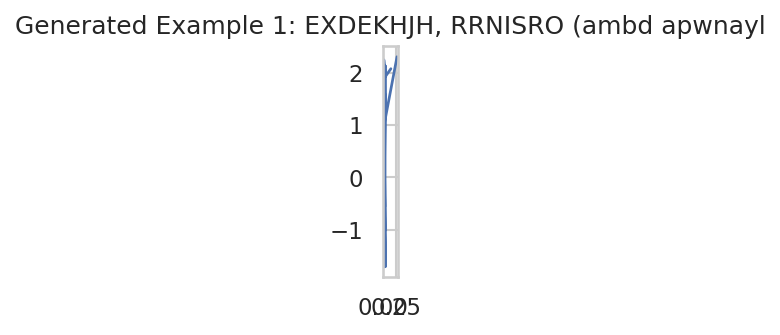

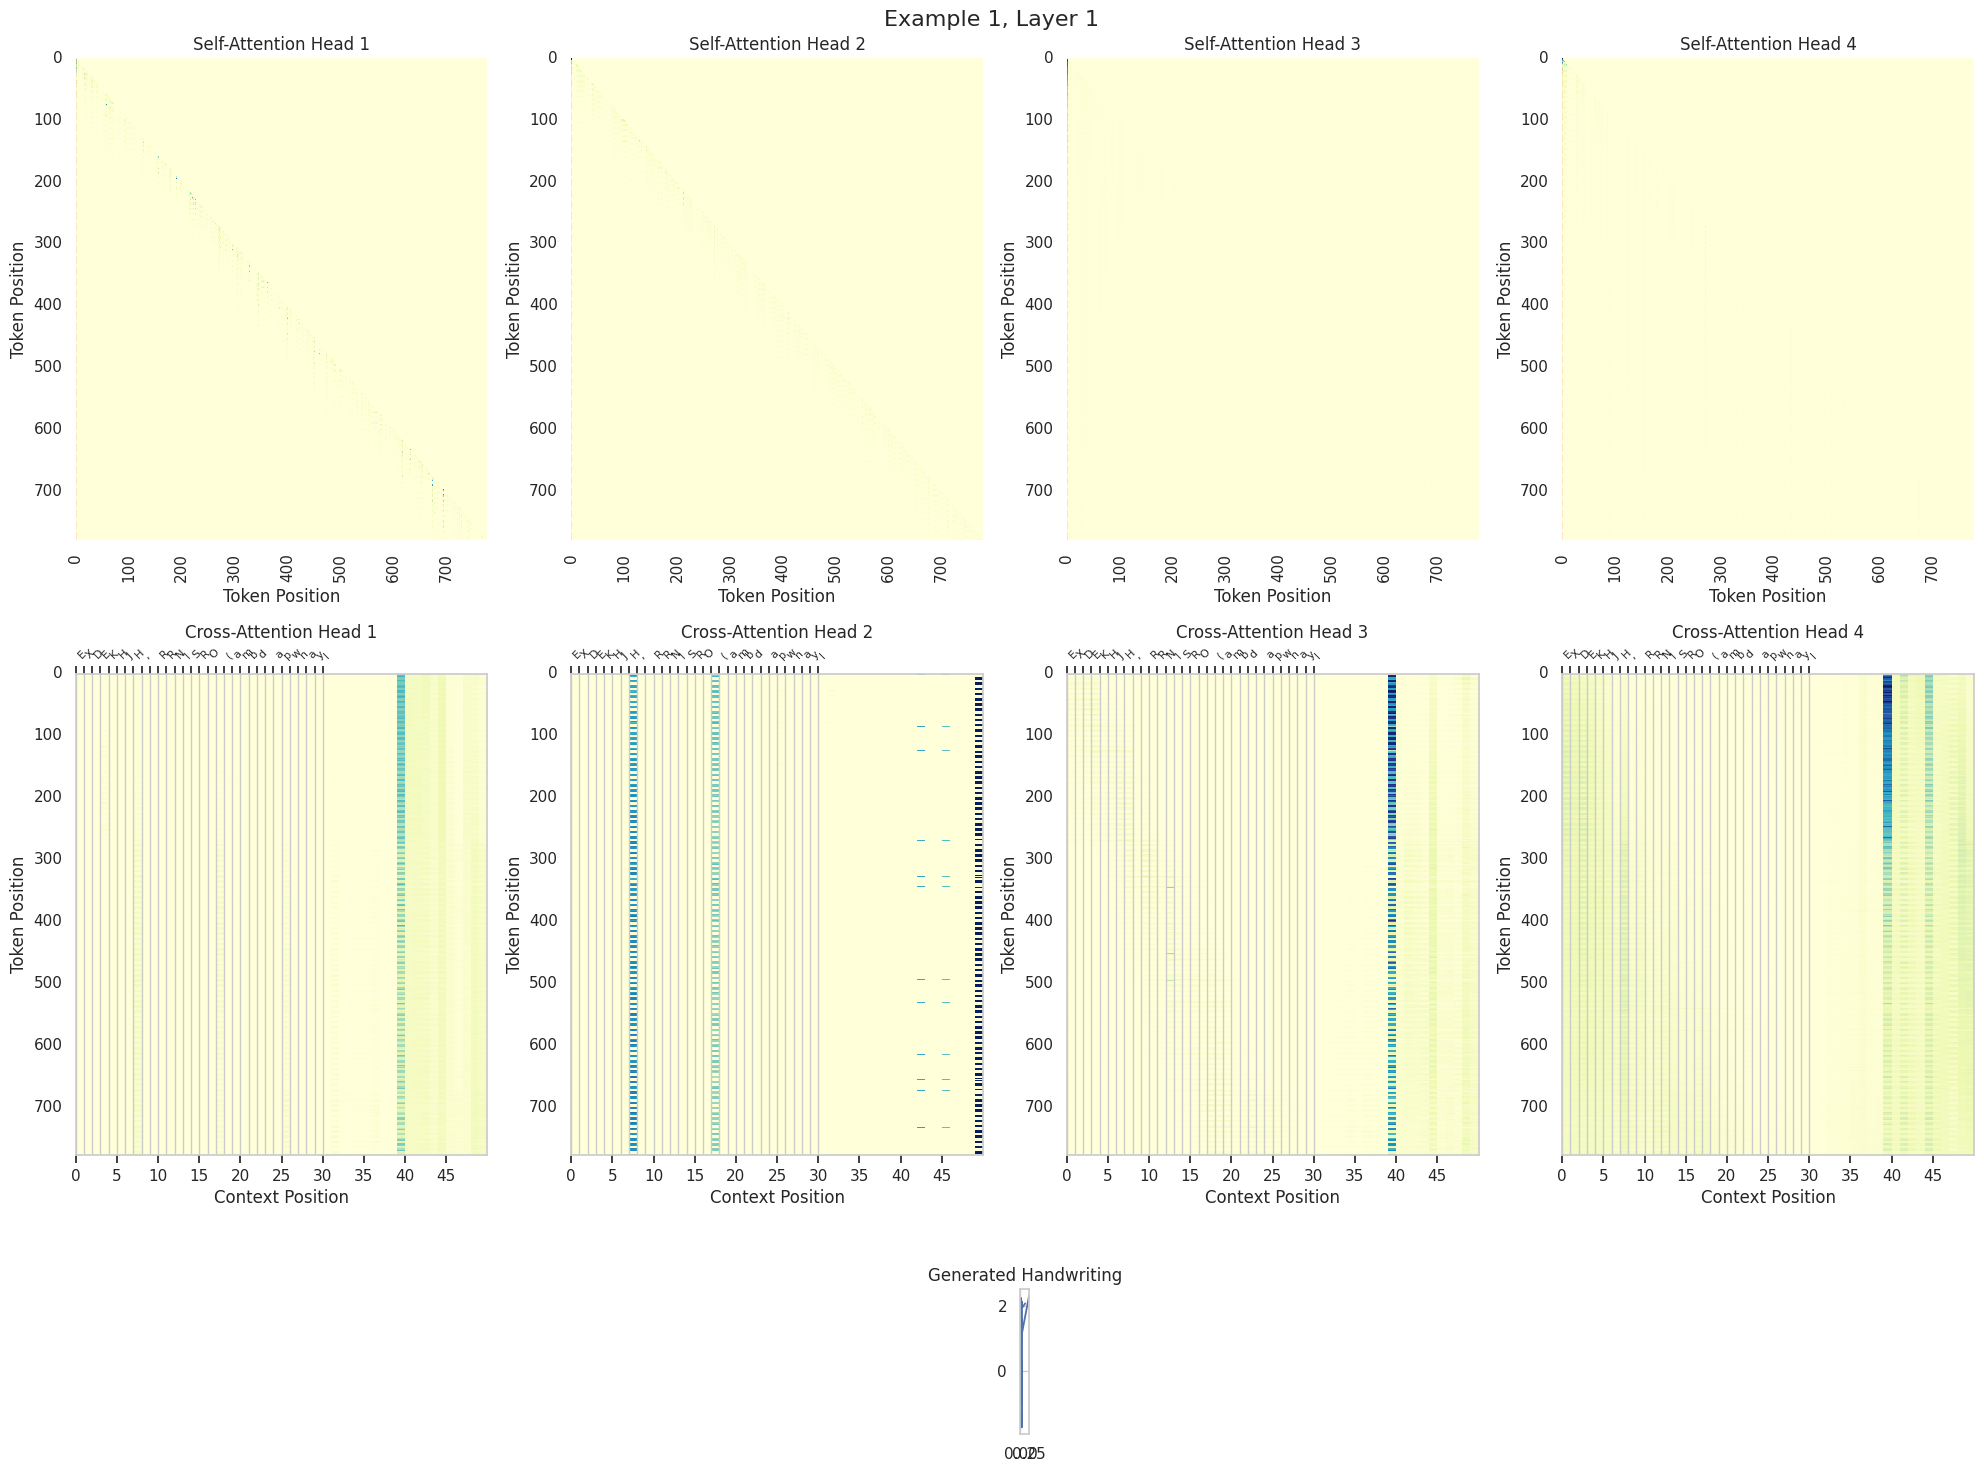

Error in callback <function flush_figures at 0x7eb351c491b0> (for post_execute):


KeyboardInterrupt: 

In [19]:
def plot_attention(model, dataset, num_examples=1):
    hooks = []
    for layer in model.transformer.h:
        self_hook = layer.attn.register_forward_hook(self_attn_hook)
        cross_hook = layer.cross_attn.register_forward_hook(cross_attn_hook)
        hooks.extend([self_hook, cross_hook])

    try:
        for i in range(num_examples):
            # Get example text from dataset
            _, c, _ = dataset[i]
            decoded_ascii_text = dataset.decode_text(c)

            # Generate new sample using the text
            offset_samp, generated_points = generate_helper_fn(
                model,
                dataset,
                word_list=decoded_ascii_text.split(' '),
                num_steps=1050,
                do_sample=False,
                temperature=1.0,
                n_words=args.num_words
            )

            # Plot the generated strokes
            plot_strokes(generated_points, f"Generated Example {i+1}: {decoded_ascii_text}")

            # Visualize attention patterns for each layer
            for layer_idx in range(len(model.transformer.h)):
                self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()
                cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()

                visualize_attention_patterns(
                    self_attn,
                    cross_attn,
                    f"Example {i+1}, Layer {layer_idx+1}",
                    generated_points,
                    decoded_ascii_text
                )
    finally:
        for hook in hooks:
            hook.remove()

plot_attention(model, test_dataset)

In [13]:
def calculate_entropy(logits):
    """Calculate entropy from logits tensor"""
    # Convert logits to probabilities using softmax
    probs = F.softmax(logits, dim=-1)
    # Calculate entropy: -sum(p * log(p))
    entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=-1)
    return entropy

def get_token_entropies(model, dataset, text):
    """Get entropy values for each token in the generated sequence"""
    logits_patterns['steps'] = []  # Reset stored logits

    # Register hook for logits
    logits_hook_handle = model.lm_head.register_forward_hook(logits_hook)

    try:
        # Generate sequence
        offset_samp, generated_points = generate_helper_fn(
            model,
            dataset,
            text=text,
            num_steps=1050,
            do_sample=False,
            temperature=1.0,
            n_words=4
        )

        # Calculate entropy for each timestep
        entropies = []
        for step_logits in logits_patterns['steps']:
            step_entropy = calculate_entropy(step_logits)
            # Convert to scalar value by taking mean across batch dimension if needed
            if len(step_entropy.shape) > 0:
                step_entropy = step_entropy.mean()
            entropies.append(float(step_entropy.cpu().numpy()))

        # Convert to numpy array
        entropies = np.array(entropies)

        return entropies, generated_points

    finally:
        # Remove the hook
        logits_hook_handle.remove()

In [14]:
def plot_strokes_with_entropy(stroke_points, entropies, title="", fig=None, ax=None, figsize=(15, 8), dpi=150):
    """Plot strokes with entropy visualization"""
    if fig is None or ax is None:
        fig = plt.figure(figsize=figsize, dpi=dpi)
        # Create grid with more space for strokes
        gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.3)
        ax_strokes = fig.add_subplot(gs[0])
        ax_entropy = fig.add_subplot(gs[1])

    # Plot strokes
    strokes = []
    current_stroke = []
    for point in stroke_points:
        if point[2] == 1:  # Pen is down
            current_stroke.append(point)
        else:  # Pen is up
            if current_stroke:
                strokes.append(current_stroke)
                current_stroke = []
    if current_stroke:
        strokes.append(current_stroke)

    # Create color gradient based on entropy
    norm = plt.Normalize(entropies.min(), entropies.max())
    cmap = plt.cm.viridis

    # Plot each stroke with color based on entropy
    for stroke in strokes:
        x, y = zip(*[(p[0], 1 - p[1]) for p in stroke])

        # Plot the stroke with varying colors
        for i in range(len(x)-1):
            idx = int((i / len(stroke)) * len(entropies))
            color = cmap(norm(entropies[idx]))
            ax_strokes.plot(x[i:i+2], y[i:i+2], color=color, linewidth=2)

    # Adjust stroke plot
    ax_strokes.set_aspect('equal')
    ax_strokes.set_title(title, pad=20, fontsize=14)
    ax_strokes.set_xticks([])
    ax_strokes.set_yticks([])

    # Plot entropy
    time_points = np.linspace(0, 1, len(entropies))
    ax_entropy.plot(time_points, entropies, color='blue', alpha=0.8, linewidth=2)
    ax_entropy.fill_between(time_points, entropies, alpha=0.2)
    ax_entropy.set_xlabel('Generation Progress', fontsize=12)
    ax_entropy.set_ylabel('Entropy', fontsize=12)
    ax_entropy.grid(True, alpha=0.3)

    # Add colorbar
    norm = plt.Normalize(entropies.min(), entropies.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax_entropy, label='Entropy', orientation='horizontal', pad=0.2)
    cbar.ax.set_title('Entropy Scale', pad=10)

    plt.tight_layout()
    return fig, (ax_strokes, ax_entropy)

In [15]:
def visualize_generation_with_entropy(model, dataset, text):
    # Get entropies and generated points
    entropies, generated_points = get_token_entropies(model, dataset, text)

    # Create visualization
    fig, (ax_strokes, ax_entropy) = plot_strokes_with_entropy(
        generated_points,
        entropies,
        title=f'Generated Text: "{text}"'
    )

    return fig

In [16]:
_ = visualize_generation_with_entropy(model, test_dataset, "Hello, world!")

TypeError: generate_helper_fn() got an unexpected keyword argument 'text'

---
# Scratch

In [ ]:
import matplotlib.gridspec as gridspec

def plot_attention_journal_v2(model, dataset, example_idx=0, head_idx=0):
    """
    Creates a more focused visualization showing the relationship between
    handwriting generation and attention patterns.
    """
    # Set up hooks
    hooks = []
    for layer in model.transformer.h:
        self_hook = layer.attn.register_forward_hook(self_attn_hook)
        cross_hook = layer.cross_attn.register_forward_hook(cross_attn_hook)
        hooks.extend([self_hook, cross_hook])

    try:
        # Generate sample
        _, c, _ = dataset[example_idx]
        decoded_ascii_text = dataset.decode_text(c)
        offset_samp, generated_points = generate_helper_fn(
            model, dataset, text=decoded_ascii_text,
            num_steps=1250, do_sample=False, temperature=1.0,
            n_words=args.num_words
        )

        # Create figure
        fig = plt.figure(figsize=(11, 8.5))  # Landscape orientation

        # Create main grid: 3 columns
        gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 2, 2])

        # Top row: Handwriting sample spanning all columns
        ax_writing = fig.add_subplot(gs[0, :])
        plot_strokes(generated_points, "", fig=fig, ax=ax_writing)
        ax_writing.set_title(f"Input Text: '{decoded_ascii_text}'", pad=10)

        # Get representative attention patterns
        # Choose an interesting layer (e.g., middle layer)
        layer_idx = len(model.transformer.h) // 2
        self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()
        cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()

        # Middle row: Self-attention analysis
        ax_self = fig.add_subplot(gs[1, :])
        im_self = sns.heatmap(
            self_attn[head_idx],
            ax=ax_self,
            cmap="YlGnBu",
            cbar_kws={'label': 'Self-Attention Weight'},
            xticklabels=200,  # Show fewer ticks
            yticklabels=200
        )
        ax_self.set_title("Self-Attention Pattern (Token-to-Token)")
        ax_self.set_xlabel("Generated Sequence Position")
        ax_self.set_ylabel("Generated Sequence Position")

        # Bottom row: Cross-attention analysis
        ax_cross = fig.add_subplot(gs[2, :])
        im_cross = sns.heatmap(
            cross_attn[head_idx],
            ax=ax_cross,
            cmap="YlGnBu",
            cbar_kws={'label': 'Cross-Attention Weight'},
            xticklabels=True,
            yticklabels=200
        )
        ax_cross.set_title("Cross-Attention Pattern (Token-to-Character)")
        ax_cross.set_xlabel("Input Text Position")
        ax_cross.set_ylabel("Generated Sequence Position")

        # Add character labels for cross-attention
        ax_cross_top = ax_cross.twiny()
        ax_cross_top.set_xlim(ax_cross.get_xlim())
        ax_cross_top.set_xticks(np.arange(len(decoded_ascii_text)))
        ax_cross_top.set_xticklabels(
            list(decoded_ascii_text),
            rotation=0,
            ha='center',
            fontsize=10
        )

        # Add alignment lines
        stroke_positions = np.linspace(0, self_attn.shape[1], len(generated_points))
        for pos in stroke_positions[::100]:  # Add lines every 100 positions
            ax_self.axvline(x=pos, color='red', alpha=0.1, linestyle='--')
            ax_self.axhline(y=pos, color='red', alpha=0.1, linestyle='--')
            ax_cross.axhline(y=pos, color='red', alpha=0.1, linestyle='--')

        plt.suptitle(
            "Attention Pattern Analysis in Handwriting Generation\n" +
            f"Layer {layer_idx + 1}, Head {head_idx + 1}",
            y=0.98
        )

        plt.tight_layout()
        return fig

    finally:
        for hook in hooks:
            hook.remove()

fig = plot_attention_journal_v2(model, test_dataset)
plt.show()